# Lab 6.01 - Regression analysis

In [2]:
# Package imports
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Dataframe
import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic plot
import seaborn as sns                               # Advanced dataviz
from sklearn.linear_model import LinearRegression

## Exercise 1: Relation between heart weight and body weight in Cats

### Part 1

Perform a linear regression analysis on the variables body weight (`Bwt`, dependent variable) and heart weight (`Hwt`, independent variabele).


1. Import the dataset `Cats.csv`.


In [3]:
cats = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/Cats.csv')
# Show the first few records of the Data Frame
cats.head()

,ID,Sex,Hwt,Bwt
0,1,F,2.0,7.0
1,2,F,2.0,7.4
2,3,F,2.0,9.5
3,4,F,2.1,7.2
4,5,F,2.1,7.3


2. Draw a scatter plot of both variables.


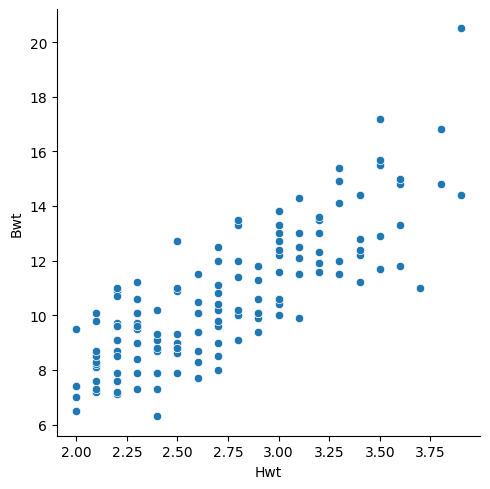

In [4]:
sns.relplot(data=cats,  x='Hwt', y='Bwt')

3. Calculate and draw the regression line.


<Axes: xlabel='Hwt', ylabel='Bwt'>

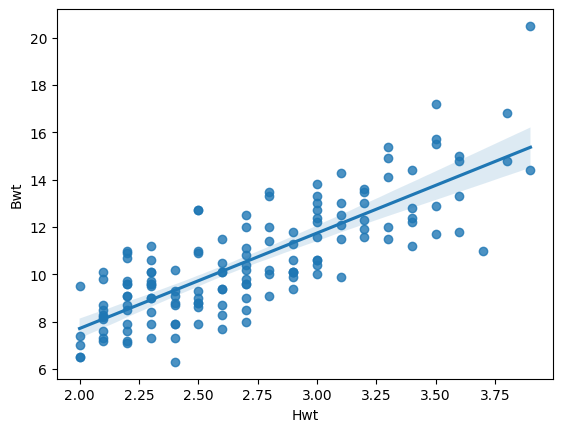

In [8]:
sns.regplot(data=cats, x='Hwt', y='Bwt')

In [10]:
b1, b0 = np.polyfit(x=cats.Hwt, y=cats.Bwt, deg=1)
print(f"Regression line: ŷ = {b0} + {b1}x")

Regression line: ŷ = -0.3510783771969617 + 4.031757486783179x


4. Calculate the correlation coefficient and the coefficient of determination.

In [ ]:
cor = np.corrcoef(
    cats.Hwt,
    cats.Bwt)[0][1]
print(f"R ≈ {cor:.4f}")
print(f"R² ≈ {cor ** 2:.4f}")

R ≈ 0.8041
R² ≈ 0.6466


5. Interpret the results from the previous steps.

Depending on the value of $|R|$ (or $R^2$), you can draw a conclusion about the strength of the linear relation between the two variables:

| $abs(R)$  |  $R^2$   | Explained variance |   Linear relation    |
| :-------: | :------: | :----------------: | :------------------: |
|   < .3    |   < .1   |       < 10%        |      very weak       |
|  .3 - .5  | .1 - .25 |     10% - 25%      |         weak         |
|  .5 - .7  | .25 - .5 |     25% - 50%      |       moderate       |
| .7 - .85  | .5 - .75 |     50% - 75%      |        strong        |
| .85 - .95 | .75 - .9 |     75% - 90%      |     very strong      |
|   > .95   |   > .9   |       > 90%        | exceptionally strong |

### Conclusion

> increasing and strong linear relation  
> R² ~ 0.6466 -> 64.66% of de variance of de dependent variable can be explained by the independant variable

### Part 2

1. Perform a linear regression analysis on the variables body weight (`Bwt`) and heart weight (`Hwt`), but this time **subdivided by gender** (`Sex`). Use the same dataset (`Cats.csv`).


In [ ]:
cats = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/Cats.csv')
# Show the first few records of the Data Frame
cats.head()

2. Draw a scatter plot of both variables for each gender.


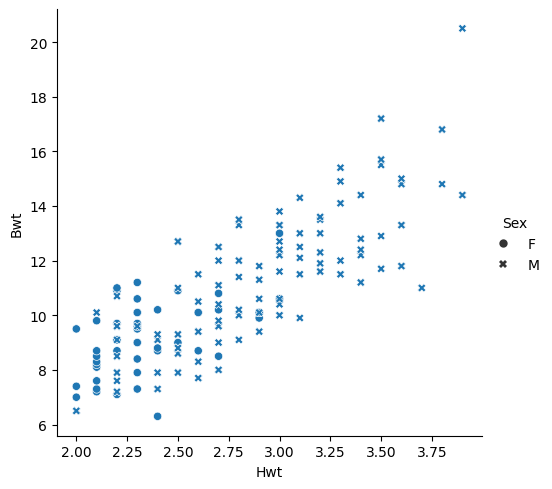

In [14]:
sns.relplot(data=cats,  x='Hwt', y='Bwt', style='Sex')

3. Calculate and draw the regression line.


Regression line: ŷ = -1.1768252533094905 + 4.309818875119162x


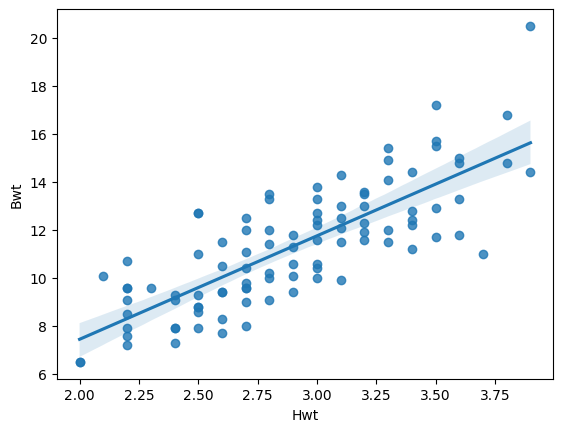

In [16]:
sns.regplot(data=cats[cats['Sex'] == 'M'], x='Hwt', y='Bwt')
b1, b0 = np.polyfit(x=cats[cats['Sex'] == 'M']['Hwt'], y=cats[cats['Sex'] == 'M']['Bwt'], deg=1)
print(f"Regression line: ŷ = {b0} + {b1}x")

Regression line: ŷ = 2.981312384473199 + 2.6364140480591503x


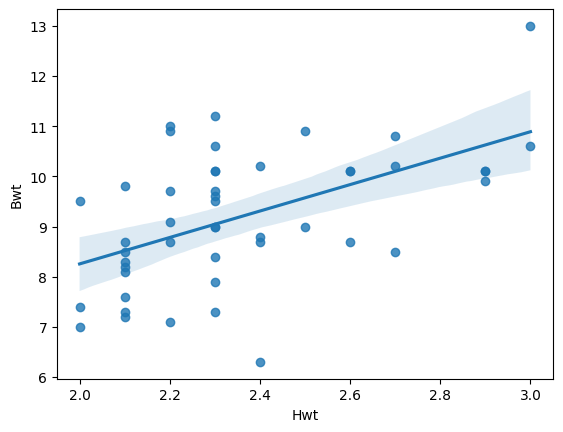

In [17]:
sns.regplot(data=cats[cats['Sex'] == 'F'], x='Hwt', y='Bwt')
b1, b0 = np.polyfit(x=cats[cats['Sex'] == 'F']['Hwt'], y=cats[cats['Sex'] == 'F']['Bwt'], deg=1)
print(f"Regression line: ŷ = {b0} + {b1}x")

4. Calculate the correlation coefficient and the coefficient of determination.


In [19]:
cor = np.corrcoef(
    cats[cats['Sex'] == 'M']['Hwt'],
    cats[cats['Sex'] == 'M']['Bwt'])[0][1]
print(f"R ≈ {cor:.4f}")
print(f"R² ≈ {cor ** 2:.4f}")

R ≈ 0.7930
R² ≈ 0.6289


In [18]:
cor = np.corrcoef(
    cats[cats['Sex'] == 'F']['Hwt'],
    cats[cats['Sex'] == 'F']['Bwt'])[0][1]
print(f"R ≈ {cor:.4f}")
print(f"R² ≈ {cor ** 2:.4f}")

R ≈ 0.5320
R² ≈ 0.2831


5. Interpret the results from the previous steps.

### Conclusion
Depending on the value of $|R|$ (or $R^2$), you can draw a conclusion about the strength of the linear relation between the two variables:

| $abs(R)$  |  $R^2$   | Explained variance |   Linear relation    |
| :-------: | :------: | :----------------: | :------------------: |
|   < .3    |   < .1   |       < 10%        |      very weak       |
|  .3 - .5  | .1 - .25 |     10% - 25%      |         weak         |
|  .5 - .7  | .25 - .5 |     25% - 50%      |       moderate       |
| .7 - .85  | .5 - .75 |     50% - 75%      |        strong        |
| .85 - .95 | .75 - .9 |     75% - 90%      |     very strong      |
|   > .95   |   > .9   |       > 90%        | exceptionally strong |
#### For the males
> increasing and strong linear relation  
> R² ~ 0.6289 -> 62.89% of de variance of de dependent variable can be explained by the independant variable
#### For the females
> increasing and moderate linear relation  
> R² ~ 0.2831 -> 28.31% of de variance of de dependent variable can be explained by the independant variable

### Answers

| Selection |  $\beta_0$ | $\beta_1$ |       $R$ |     $R^2$ |
| :-------- | ---------: | --------: | --------: | --------: |
| All       | -0.3510784 | 4.0317575 | 0.8041348 | 0.6466328 |
| Male      | -1.1768253 | 4.3098189 | 0.7930443 | 0.6289193 |
| Female    |  2.9813124 |  2.636414 | 0.5320497 | 0.2830768 |
